# Florida highway noise barriers — overview, cleaning & school matching

**Source.** `noise_barriers_jul26.gdb` — the FDOT statewide noise-barrier
inventory, distributed through the Florida Geographic Data Library (FGDL) and
maintained by the University of Florida GeoPlan Center. Snapshot: **July 2026**;
record-level updates are tracked from 2019 onward. Fetched with
`python -m src.cli florida data noise-barriers fetch` into
`data/florida/noise_barriers/raw/`.
Metadata: <https://fgdl.org/zips/metadata/xml/noise_barriers_jul26.xml>

**Schools.** NCES EDGE geocodes for public schools, 2024–25
(<https://nces.ed.gov/programs/edge/geographic/schoollocations>).

**This notebook**
1. loads the barrier layer and documents its fields,
2. gives thorough descriptives (record type, verification status, construction
   year, physical dimensions, geography) with figures on a web-tile basemap,
3. derives a clean "physically-present barriers" subset,
4. loads and filters the Florida school points,
5. matches schools to barriers (nearest distance, counts / barrier length inside
   distance buffers) and shows worked examples on a basemap,
6. persists the exploratory per-school feature table (the clean barrier
   layer is now the `noise-barriers preprocess` pipeline step).

**Note.** §3.3–3.6 describe the *raw barrier-record* inventory (all ~2.7k records, including recommended/removed/private walls) — that grain doesn't survive into the final event-study panel, which only carries per-*school* proximity features, so it has no home in [`descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb) and stays here. That notebook does cover the geography of *treated schools*, for comparison.

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import contextily as cx

warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")

import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import np, pd, plt

pd.set_option("display.max_columns", 60)
BARRIERS_GDB = ROOT / "data/florida/noise_barriers/raw/noise_barriers_jul26.gdb"
SCHOOLS_SHP = ROOT / "data/florida/schools/EDGE_GEOCODE_PUBLICSCH_2425/Shapefile_SCH/EDGE_GEOCODE_PUBLICSCH_2425.shp"
PROCESSED = ROOT / "data/florida/noise_barriers/processed"
FIGDIR = ROOT / "output/figures/florida"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)
assert BARRIERS_GDB.exists(), (
    f"{BARRIERS_GDB} missing — run `python -m src.cli florida data noise-barriers fetch` first"
)

# Florida GDL Albers — metres, equal-area; good for distances statewide.
CRS_M = 3087
# Web-Mercator, for pulling basemap tiles.
CRS_TILE = 3857
# Upper bound for a plausible construction year (the register carries a few
# rows dated to next year for programmed walls).
MAX_YEAR = pd.Timestamp.now().year + 1

# Esri tiles need no API key and are not user-agent gated (unlike the current
# CartoDB / OSM public endpoints, which now return placeholder tiles).
BASEMAP_LIGHT = cx.providers.Esri.WorldGrayCanvas
BASEMAP_STREET = cx.providers.Esri.WorldStreetMap


def add_basemap(ax, crs=CRS_M, source=BASEMAP_LIGHT, **kw):
    """Drop an online-tile basemap behind whatever is already on `ax`."""
    cx.add_basemap(ax, crs=crs, source=source, attribution_size=6, **kw)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("wrote", path.relative_to(ROOT))


ROOT

PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. Load

In [2]:
barriers = gpd.read_file(BARRIERS_GDB)
print("rows:", len(barriers), "| columns:", barriers.shape[1])
print("CRS :", barriers.crs.to_epsg(), "(", barriers.crs.name, ")")
print("geometry types:", barriers.geom_type.value_counts().to_dict())

xmin, ymin, xmax, ymax = barriers.total_bounds
print(f"extent (m): x {xmin:,.0f}..{xmax:,.0f}  y {ymin:,.0f}..{ymax:,.0f}")
barriers.head(3)

rows: 1883 | columns: 63
CRS : 3087 ( NAD83(HARN) / Florida GDL Albers )
geometry types: {'MultiLineString': 1883}
extent (m): x 76,023..793,008  y 166,767..749,553


,FHWA_ID,FPN_NO,FM_ID,ROADWAY,FED_ROUTE,APPROX_LOC,FDOT_DISTR,TYPE,FED_STREF,FED_STATE,FED_COUNTY,FED_CITY,ZIPCODE,BARRIER_ID,FED_COST,FED_CYCOST,FED_COSTFT,FED_CYUNIT,FED_HEIGHT,FED_LENGTH,FED_AREA,FED_YRCON,FED_ANR,FED_NAC,FED_ONAC,BEN_RCPTRS,TOT_RCPTRS,RCPTR_NOTE,RCPTR_FLAG,FED_MATERL,...,FED_FNDTN,FED_PTYPE,FED_MDATE,FED_GISLOB,BLOC_ONRTE,BLOC_SIDE,BLOC_BND,COMMENTS,NOTES,OTHER_LINK,PDF_LINKS,SWEPT_YN,FR_LAT,FR_LONG,T_LAT,T_LONG,G_LENGTH,TBR_NOTE,FHWA_SUB_NOTES,SOURCE,MGRS,GOOGLEMAP,GCID,DESCRIPT,FLAG,UPDATE_DAY,FGDLAQDATE,AUTOID,SHAPE_Length,geometry
0,14603,,257139-1,15120000,SR 688 / Ulmerton Road,LEISURE WORLD MOBILE HOME PARK,7,CONSTRUCTED BARRIERS,"FDOT DISTRICT: 7, ID: 131",Florida,Pinellas,Clearwater,33760,,169200,0,30.0,0.0,8,705,5640,2008,7.0,B,,0.0,0.0,,,Block,...,Ground Mounted,S,Federal Regulation,"27.89400679 -82.72060856,27.89408746 -82.71844401",NON-SHOULDER MOUNTED,NORTH,WEST,LEISURE WORLD MHP - LEISURE WORLD MHP,,,,N-B09,27.894007,-82.720609,27.894087,-82.718444,698.0,ANR 7.0 IS AVERAGE DESIGN GOAL FED_MATERL UPDA...,EXISTING IN 2022 FHWA SUBMISSION,GEOPLAN CENTER,17RLL3075286656,https://www.google.com/maps/place/17RLL3075286656,131,SR 688 / ULMERTON ROAD,V,2021-02-23 00:00:00+00:00,2026-07-29 00:00:00+00:00,26,212.862599,"MULTILINESTRING ((525695.826 432676.67, 525744..."
1,14604,,257139-1,15120000,SR 688 / Ulmerton Road,MARINERS COVE MHP,7,CONSTRUCTED BARRIERS,"FDOT DISTRICT: 7, ID: 132",Florida,Pinellas,Clearwater,33760,,76560,0,30.0,0.0,8,319,2552,2008,7.0,B,,0.0,0.0,,,Precast Concrete,...,Ground Mounted,S,Federal Regulation,"27.89365933 -82.71230345,27.89365135 -82.7111526",NON-SHOULDER MOUNTED,SOUTH,EAST,MARINERS COVE - MARINERS COVE,,,,N-B09,27.893659,-82.712303,27.893651,-82.711153,372.0,ANR 7.0 IS AVERAGE DESIGN GOAL,EXISTING IN 2022 FHWA SUBMISSION,GEOPLAN CENTER,17RLL3151986599,https://www.google.com/maps/place/17RLL3151986599,132,SR 688 / ULMERTON ROAD,V,2017-03-13 00:00:00+00:00,2026-07-29 00:00:00+00:00,27,113.347204,"MULTILINESTRING ((526512.148 432646.578, 52653..."
2,14402,,258443-1,10320800,I-275,BUSCH BLVD TO LINEBAUGH AVE,7,CONSTRUCTED BARRIERS,"FDOT DISTRICT: 7, ID: 133",Florida,Hillsborough,Tampa,33612,,693600,0,30.0,0.0,20,1156,23120,2007,7.0,B,,0.0,0.0,,,Precast Concrete,...,Ground Mounted,I,Federal Regulation,"28.03659006 -82.45537725,28.03976584 -82.45523947",NON-SHOULDER MOUNTED,WEST,SOUTH,NW CORNER OF PARKING LOT (BUSCH/FLORIDA) TO LI...,,,,N-B09,28.036590,-82.455377,28.039766,-82.455239,1161.0,ANR 7.0 IS AVERAGE DESIGN GOAL,EXISTING IN 2022 FHWA SUBMISSION,GEOPLAN CENTER,17RLM5695802286,https://www.google.com/maps/place/17RLM5695802286,133,I-275,V,2014-09-24 00:00:00+00:00,2026-07-29 00:00:00+00:00,28,353.862378,"MULTILINESTRING ((551554.31 448808.39, 551561...."


## 2. Field dictionary

The layer carries ~63 columns; the ones this notebook uses:

| field | meaning | notes |
|---|---|---|
| `TYPE` | record status | `CONSTRUCTED` / `REPLACED` = wall physically present; `RECOMMENDED` / `PLANNED` = study output, not built; `REMOVED` = gone or a retired record; `PRIVATE WALL` / `PERIMETER WALL` = non-FDOT screening |
| `FLAG` | field verification | `V*` verified (several sub-codes: `V`, `VSNA`, `V FRM`…), `NV` not verified, `FNV` future / not verified, `DEL` deleted |
| `FED_YRCON` | year of original construction | `9999` (and `0`) are sentinels for "unknown / not applicable"; a few programmed walls are dated to next year |
| `FED_HEIGHT` | average height | **feet** |
| `FED_LENGTH` | barrier length | **feet** (agency-reported) |
| `FED_AREA` | barrier face area | **square feet** |
| `G_LENGTH` | GIS-derived length | **feet** |
| `SHAPE_Length` | geometry length | **metres** (layer CRS is EPSG:3087) |
| `FDOT_DISTR` | FDOT district | `1`–`7`, plus `TURNPIKE` and `CFX` (toll authorities) |
| `FED_NAC` | FHWA Noise Abatement Category | A–G land-use class |
| `FED_ANR` | average noise reduction | dB(A) design benefit |
| `BEN_RCPTRS` / `TOT_RCPTRS` | benefited receptors | count meeting / including the 5 dB(A) threshold |
| `FED_MATERL` | primary material | ~11 % missing |
| `FHWA_SUB_NOTES` | FHWA inventory submission tag (2022 / 2025 / 2028 cycles) | NEW / EXISTING / DEMO / SAVE FOR |
| `FED_COUNTY`, `FED_ROUTE` | county, highway route | |

## 3. Overview descriptives

### 3.1 Record type

In [3]:
print(barriers["TYPE"].value_counts(), "\n")
# "physically present today" = a wall you could stand next to
present_types = ["CONSTRUCTED BARRIERS", "REPLACED BARRIERS"]
print("physically present (CONSTRUCTED + REPLACED):",
      barriers["TYPE"].isin(present_types).sum())
print("study-only (RECOMMENDED / PLANNED)          :",
      barriers["TYPE"].isin(["RECOMMENDED BARRIERS", "PLANNED BARRIERS"]).sum())

TYPE
CONSTRUCTED BARRIERS    1235
RECOMMENDED BARRIERS     549
REMOVED BARRIERS          71
PRIVATE WALL              11
REPLACED BARRIERS         10
PERIMETER WALL             7
Name: count, dtype: int64 

physically present (CONSTRUCTED + REPLACED): 1245
study-only (RECOMMENDED / PLANNED)          : 549


### 3.2 Verification & inventory status

In [4]:
present_mask = barriers["TYPE"].isin(["CONSTRUCTED BARRIERS", "REPLACED BARRIERS"])
print("FLAG:\n", barriers["FLAG"].value_counts(dropna=False), "\n")
flag_bucket = barriers["FLAG"].str[0].map({"V": "V*", "N": "NV", "F": "FNV", "D": "DEL"})
print("TYPE x FLAG (bucketed):\n", pd.crosstab(barriers["TYPE"], flag_bucket), "\n")
print("FHWA_SUB_NOTES:\n", barriers["FHWA_SUB_NOTES"].value_counts(dropna=False), "\n")

vshare = barriers.loc[present_mask, "FLAG"].str.startswith("V").mean()
fshare = barriers.loc[present_mask, "FLAG"].eq("FNV").mean()
print(f"present walls: {vshare:.0%} field-verified (V*), {fshare:.0%} FNV (programmed / in construction)")

FLAG:
 FLAG
V        831
NV       585
FNV      234
VSNA     136
DEL       81
V FRM     11
V FPR      4
V SHO      1
Name: count, dtype: int64 

TYPE x FLAG (bucketed):
 FLAG                  DEL  FNV   NV   V*
TYPE                                    
CONSTRUCTED BARRIERS    0  230   40  965
PERIMETER WALL          0    0    0    7
PRIVATE WALL            0    0    0   11
RECOMMENDED BARRIERS    0    4  545    0
REMOVED BARRIERS       71    0    0    0
REPLACED BARRIERS      10    0    0    0 

FHWA_SUB_NOTES:
 FHWA_SUB_NOTES
EXISTING IN 2022 FHWA SUBMISSION         942
NaN                                      615
NEW IN 2025 FHWA SUBMISSION              169
NEW IN 2022 FHWA SUBMISSION              116
SAVE FOR 2028 FHWA SUBMISSION             17
NEW DEMO IN 2022 FHWA SUBMISSION          10
EXISTING DEMO IN 2022 FHWA SUBMISSION      6
NOT FOR FHWA SUBMISSION                    5
EDITED IN 2025 FHWA SUBMISSION             3
Name: count, dtype: int64 

present walls: 78% field-verified (V

`DEL` is confined to `REMOVED` / `REPLACED` rows; `RECOMMENDED` rows are `NV`.
Most present walls are field-verified; the `FNV` share is programmed or
under-construction walls at snapshot time.

### 3.3 Construction year

sentinel 9999: 591  | sentinel 0: 0  | plausible 1960-2027: 1292

valid-year coverage by TYPE:
                      n_valid     min     max
TYPE                                         
CONSTRUCTED BARRIERS     1235  1977.0  2026.0
PERIMETER WALL              7  2016.0  2024.0
PRIVATE WALL               11  2000.0  2019.0
RECOMMENDED BARRIERS        2  1995.0  2025.0
REMOVED BARRIERS           27  1991.0  2021.0
REPLACED BARRIERS          10  1983.0  2009.0

present walls by decade of construction:
 FED_YRCON
1970      4
1980     13
1990    108
2000    451
2010    382
2020    287
Name: count, dtype: int64


wrote output/figures/florida/barriers_by_decade.png


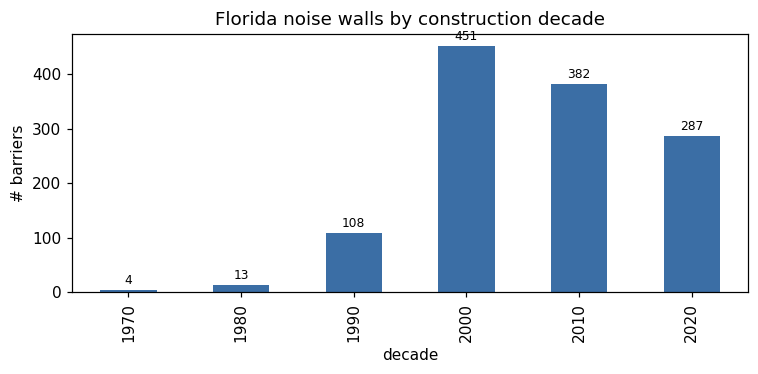

In [5]:
yr = barriers["FED_YRCON"]
print(f"sentinel 9999: {(yr == 9999).sum()}  | sentinel 0: {(yr == 0).sum()}"
      f"  | plausible 1960-{MAX_YEAR}: {yr.between(1960, MAX_YEAR).sum()}")

valid_yr = yr.where(yr.between(1960, MAX_YEAR))
print("\nvalid-year coverage by TYPE:")
print(barriers.assign(y=valid_yr).groupby("TYPE")["y"]
      .agg(n_valid="count", min="min", max="max"))

present = barriers[barriers["TYPE"].isin(present_types)].copy()
by_decade = (present["FED_YRCON"].where(present["FED_YRCON"].between(1960, MAX_YEAR))
             // 10 * 10).value_counts().sort_index()
print("\npresent walls by decade of construction:\n", by_decade)

fig, ax = plt.subplots(figsize=(7, 3.5))
by_decade.plot.bar(ax=ax, color="#3b6ea5")
ax.set(xlabel="decade", ylabel="# barriers", title="Florida noise walls by construction decade")
ax.bar_label(ax.containers[0], padding=2, fontsize=8)
fig.tight_layout()
savefig(fig, "barriers_by_decade.png")

### 3.4 Physical dimensions

present walls — dimension summary:
                min     10%      50%      90%       max
FED_HEIGHT      7.0     8.0     14.0     22.0      22.0
FED_LENGTH     30.0   339.0   1169.0   3295.2   10688.0
FED_AREA      570.0  3914.0  15442.0  60163.2  231836.0
G_LENGTH       26.0   360.6   1160.0   3292.8   10936.0
SHAPE_Length    7.8   109.9    353.7   1003.7    3333.4

SHAPE_Length(m) / G_LENGTH(ft->m):  median 1.000  [p10 1.000, p90 1.000]  -> geometry agrees with reported length


wrote output/figures/florida/barriers_segment_length_hist.png

heights are reported in whole feet: [np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22)]


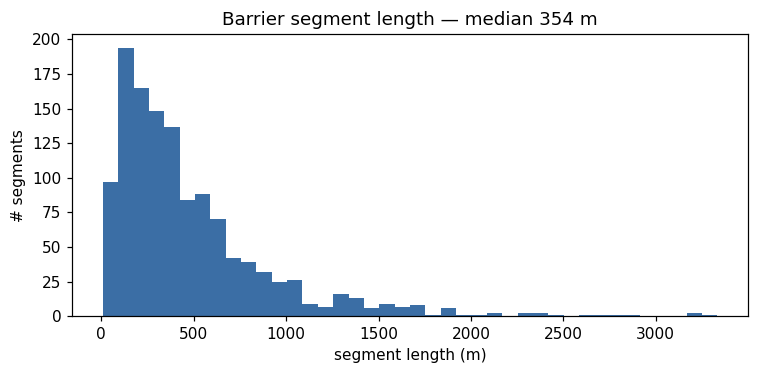

In [6]:
dims = present[["FED_HEIGHT", "FED_LENGTH", "FED_AREA", "G_LENGTH", "SHAPE_Length"]].astype(float)
print("present walls — dimension summary:")
print(dims.describe(percentiles=[.1, .25, .5, .75, .9]).round(1).T[["min", "10%", "50%", "90%", "max"]])

# Consistency check: SHAPE_Length is metres, FED_LENGTH / G_LENGTH are feet.
ratio = present["SHAPE_Length"] / (present["G_LENGTH"].replace(0, np.nan) * 0.3048)
print(f"\nSHAPE_Length(m) / G_LENGTH(ft->m):  median {ratio.median():.3f}"
      f"  [p10 {ratio.quantile(.1):.3f}, p90 {ratio.quantile(.9):.3f}]  -> geometry agrees with reported length")

fig, ax = plt.subplots(figsize=(7, 3.5))
present["SHAPE_Length"].plot.hist(bins=40, ax=ax, color="#3b6ea5")
ax.set(xlabel="segment length (m)", ylabel="# segments",
       title=f"Barrier segment length — median {present['SHAPE_Length'].median():.0f} m")
fig.tight_layout()
savefig(fig, "barriers_segment_length_hist.png")

print("\nheights are reported in whole feet:", sorted(present["FED_HEIGHT"].unique()))

### 3.5 Geography

wrote output/figures/florida/barriers_by_district_county.png
counties with >=1 present wall: 29 of 67
FED_COUNTY
Orange          260
Miami-Dade      251
Broward         206
Palm Beach      145
Hillsborough    108
Duval            69
Name: count, dtype: int64


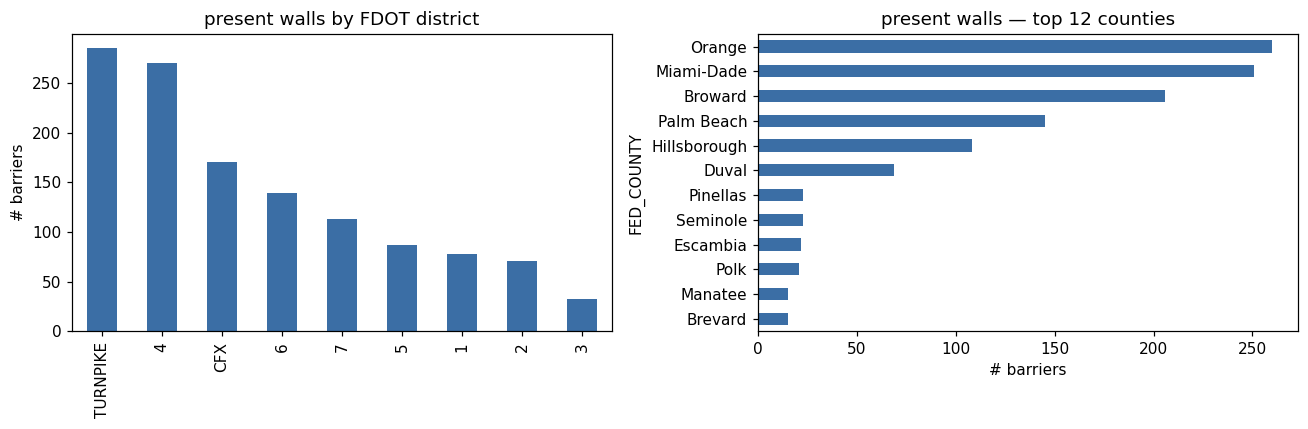

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
present["FDOT_DISTR"].value_counts().plot.bar(ax=axes[0], color="#3b6ea5")
axes[0].set(title="present walls by FDOT district", xlabel="", ylabel="# barriers")
present["FED_COUNTY"].value_counts().head(12).plot.barh(ax=axes[1], color="#3b6ea5")
axes[1].invert_yaxis()
axes[1].set(title="present walls — top 12 counties", xlabel="# barriers")
fig.tight_layout()
savefig(fig, "barriers_by_district_county.png")

print("counties with >=1 present wall:", present["FED_COUNTY"].nunique(), "of 67")
print(present["FED_COUNTY"].value_counts().head(6))

The inventory is concentrated in the three big urban corridors — South-East
Florida (Miami-Dade / Broward / Palm Beach along I-95, the Turnpike, I-595/I-75),
Metro Orlando (Orange, incl. the CFX toll roads) and Tampa Bay (Hillsborough /
Pinellas along I-275 / I-4). Rural counties have essentially none.

### 3.6 Statewide map

wrote output/figures/florida/map_statewide_by_type.png


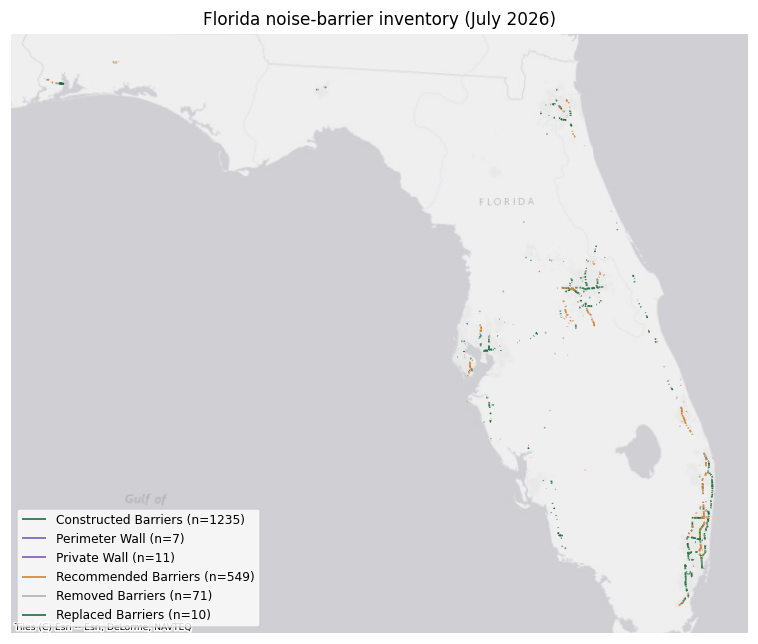

In [8]:
colors = {"CONSTRUCTED BARRIERS": "#1f6f3f", "REPLACED BARRIERS": "#1f6f3f",
          "RECOMMENDED BARRIERS": "#d9822b", "PLANNED BARRIERS": "#d9822b",
          "REMOVED BARRIERS": "#b0b0b0",
          "PRIVATE WALL": "#7b5cb8", "PERIMETER WALL": "#7b5cb8"}

fig, ax = plt.subplots(figsize=(7, 9))
for t, sub in barriers.groupby("TYPE"):
    sub.plot(ax=ax, color=colors.get(t, "#333"), linewidth=1.1,
             label=f"{t.title()} (n={len(sub)})")
add_basemap(ax, source=BASEMAP_LIGHT)
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, frameon=True)
ax.set_title("Florida noise-barrier inventory (July 2026)", fontsize=11)
fig.tight_layout()
savefig(fig, "map_statewide_by_type.png")

## 4. Cleaning

Rules for the analysis subset `barriers_clean`:

1. **Keep only physically-present walls** — `TYPE in {CONSTRUCTED, REPLACED}`.
   Drop `RECOMMENDED` / `PLANNED` (never built), `REMOVED` (gone, plus flagged
   duplicate / type-change stubs), and `PRIVATE WALL` / `PERIMETER WALL`
   (not FDOT facilities — kept separately as `other_walls`).
2. **Deduplicate** — drop any exact-geometry duplicate; `GCID` / `AUTOID` are
   1:1 with rows.
3. **Parse `built_year`** from `FED_YRCON`, mapping `9999` / `0` → `NA`.
4. **Convert units** — `height_m`, `length_m` from feet; keep `seg_len_m`
   (`SHAPE_Length`, already metres) as the geometry-true length.
5. Keep a tidy column set; reproject to EPSG:3087.

In [9]:
FT_M = 0.3048
present_types = ["CONSTRUCTED BARRIERS", "REPLACED BARRIERS"]

other_walls = (barriers[barriers["TYPE"].isin(["PRIVATE WALL", "PERIMETER WALL"])]
               .to_crs(CRS_M).reset_index(drop=True))

src = barriers[barriers["TYPE"].isin(present_types)].to_crs(CRS_M)
dup_mask = src.geometry.to_wkb().duplicated()
print(f"exact duplicate geometries among present walls: {int(dup_mask.sum())}"
      f"  | GCID unique: {src['GCID'].is_unique}  | AUTOID unique: {src['AUTOID'].is_unique}")
src = src[~dup_mask]

keep_cols = ["GCID", "TYPE", "FLAG", "FDOT_DISTR", "FED_ROUTE", "FED_COUNTY",
             "FED_NAC", "FED_ANR", "BEN_RCPTRS", "TOT_RCPTRS", "FED_MATERL",
             "FHWA_SUB_NOTES", "geometry"]

barriers_clean = (
    src.loc[:, keep_cols]
    .assign(
        built_year=lambda d: src.loc[d.index, "FED_YRCON"]
                              .where(src.loc[d.index, "FED_YRCON"].between(1960, MAX_YEAR)),
        height_m=lambda d: (src.loc[d.index, "FED_HEIGHT"] * FT_M).round(2),
        length_m=lambda d: (src.loc[d.index, "FED_LENGTH"] * FT_M).round(1),
        seg_len_m=lambda d: src.loc[d.index, "SHAPE_Length"].round(1),
    )
    .rename(columns=str.lower)
    .reset_index(drop=True)
)

print(f"\n{len(barriers)} raw  ->  {len(barriers_clean)} present walls "
      f"(+ {len(other_walls)} private/perimeter walls kept aside)")
print("built_year known for", barriers_clean["built_year"].notna().sum(),
      f"/ {len(barriers_clean)}  ({barriers_clean['built_year'].notna().mean():.0%})")
barriers_clean.head(3)

exact duplicate geometries among present walls: 0  | GCID unique: True  | AUTOID unique: True

1883 raw  ->  1245 present walls (+ 18 private/perimeter walls kept aside)
built_year known for 1245 / 1245  (100%)


,gcid,type,flag,fdot_distr,fed_route,fed_county,fed_nac,fed_anr,ben_rcptrs,tot_rcptrs,fed_materl,fhwa_sub_notes,geometry,built_year,height_m,length_m,seg_len_m
0,131,CONSTRUCTED BARRIERS,V,7,SR 688 / Ulmerton Road,Pinellas,B,7.0,0.0,0.0,Block,EXISTING IN 2022 FHWA SUBMISSION,"MULTILINESTRING ((525695.826 432676.67, 525744...",2008,2.44,214.9,212.9
1,132,CONSTRUCTED BARRIERS,V,7,SR 688 / Ulmerton Road,Pinellas,B,7.0,0.0,0.0,Precast Concrete,EXISTING IN 2022 FHWA SUBMISSION,"MULTILINESTRING ((526512.148 432646.578, 52653...",2008,2.44,97.2,113.3
2,133,CONSTRUCTED BARRIERS,V,7,I-275,Hillsborough,B,7.0,0.0,0.0,Precast Concrete,EXISTING IN 2022 FHWA SUBMISSION,"MULTILINESTRING ((551554.31 448808.39, 551561....",2007,6.10,352.3,353.9


wrote output/figures/florida/map_se_florida_clean.png


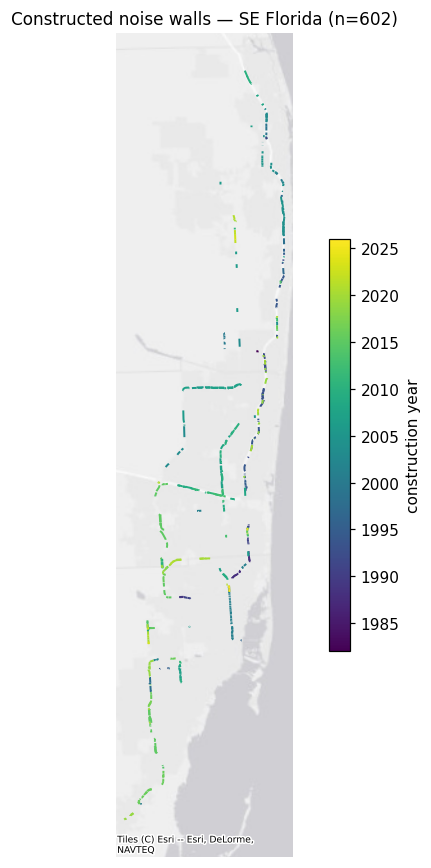

In [10]:
# SE Florida zoom — the densest part of the network.
se = barriers_clean[barriers_clean["fed_county"].isin(
    ["Miami-Dade", "Broward", "Palm Beach"])]

fig, ax = plt.subplots(figsize=(7, 8))
se.plot(ax=ax, column="built_year", cmap="viridis", linewidth=1.3, legend=True,
        legend_kwds={"label": "construction year", "shrink": 0.5},
        missing_kwds={"color": "#c0392b", "label": "year unknown"})
add_basemap(ax, source=BASEMAP_LIGHT)
ax.set_axis_off()
ax.set_title(f"Constructed noise walls — SE Florida (n={len(se)})", fontsize=11)
fig.tight_layout()
savefig(fig, "map_se_florida_clean.png")

## 5. School locations

In [11]:
schools_raw = gpd.read_file(SCHOOLS_SHP)
schools = schools_raw.query("STATE == 'FL'").to_crs(CRS_M).reset_index(drop=True)
print(f"{len(schools_raw):,} US schools  ->  {len(schools):,} Florida schools")

loc_key = schools.geometry.apply(lambda p: (round(p.x, 1), round(p.y, 1)))
print("distinct coordinates:", loc_key.nunique(),
      "| rows sharing a coordinate with another:", loc_key.duplicated(keep=False).sum(),
      "(district offices / virtual schools / co-located campuses)")
print("counties represented:", schools["NMCNTY"].nunique())
schools[["NCESSCH", "NAME", "CITY", "NMCNTY", "LAT", "LON"]].head(3)

102,178 US schools  ->  4,312 Florida schools
distinct coordinates: 3948 | rows sharing a coordinate with another: 611 (district offices / virtual schools / co-located campuses)
counties represented: 67


,NCESSCH,NAME,CITY,NMCNTY,LAT,LON
0,120000207976,FLORIDA VIRTUAL ELEMENTARY SCHOOL,ORLANDO,Orange County,28.456815,-81.453188
1,120000207982,FLORIDA VIRTUAL HIGH SCHOOL,ORLANDO,Orange County,28.456815,-81.453188
2,120000208677,FLORIDA VIRTUAL MIDDLE SCHOOL,ORLANDO,Orange County,28.456815,-81.453188


## 6. Matching schools to barriers

For every school we compute, against `barriers_clean`:

- `dist_nearest_m` — distance to the closest wall,
- `n_within_{100,300,500,1000}` — how many wall segments fall inside a buffer,
- `barrier_len_within_500m` — summed `seg_len_m` of segments intersecting the
  500 m buffer (whole-segment sum, a slight over-count for segments only
  partly inside).

Both layers are in EPSG:3087, so distances are in metres.

In [12]:
# Dense school x present-wall distance matrix (a few thousand x ~1k -> cheap).
D = np.vstack([barriers_clean.distance(p).values for p in schools.geometry])
print("distance matrix:", D.shape)

seg_len = barriers_clean["seg_len_m"].values
feat = schools[["NCESSCH", "NAME", "CITY", "NMCNTY", "NMCBSA", "geometry"]].copy()
feat["dist_nearest_m"] = D.min(axis=1).round(1)
feat["nearest_gcid"] = barriers_clean["gcid"].values[D.argmin(axis=1)]
for r in (100, 300, 500, 1000):
    feat[f"n_within_{r}"] = (D <= r).sum(axis=1)
feat["barrier_len_within_500m"] = ((D <= 500) @ seg_len).round(1)

feat.drop(columns="geometry").head()

distance matrix: (4312, 1245)


,NCESSCH,NAME,CITY,NMCNTY,NMCBSA,dist_nearest_m,nearest_gcid,n_within_100,n_within_300,n_within_500,n_within_1000,barrier_len_within_500m
0,120000207976,FLORIDA VIRTUAL ELEMENTARY SCHOOL,ORLANDO,Orange County,"Orlando-Kissimmee-Sanford, FL",1832.5,276,0,0,0,0,0.0
1,120000207982,FLORIDA VIRTUAL HIGH SCHOOL,ORLANDO,Orange County,"Orlando-Kissimmee-Sanford, FL",1832.5,276,0,0,0,0,0.0
2,120000208677,FLORIDA VIRTUAL MIDDLE SCHOOL,ORLANDO,Orange County,"Orlando-Kissimmee-Sanford, FL",1832.5,276,0,0,0,0,0.0
3,120003000002,CAROLYN BEATRICE PARKER ELEMENTARY,GAINESVILLE,Alachua County,"Gainesville, FL",58849.3,726,0,0,0,0,0.0
4,120003000003,STEPHEN FOSTER ELEMENTARY SCHOOL,GAINESVILLE,Alachua County,"Gainesville, FL",61182.4,726,0,0,0,0,0.0


 buffer_m  n_schools share_of_FL_schools  mean_n_barriers
      100         14                0.3%             1.21
      300         94                2.2%             2.29
      500        165                3.8%             2.93
     1000        434               10.1%             3.88
     2000        969               22.5%              NaN

dist_nearest_m distribution:
count      4312.0
mean      14402.0
std       24330.0
min          35.0
10%         996.0
25%        2176.0
50%        4770.0
75%       12509.0
90%       41620.0
max      164777.0
Name: dist_nearest_m, dtype: float64

top counties by share of schools within 500 m of a wall (>=20 schools):
                     n_schools  share_within_500m
NMCNTY                                           
Broward County             331               11.2
Orange County              285                9.8
Palm Beach County          241                7.5
Miami-Dade County          545                6.6
Hillsborough County        310  

wrote output/figures/florida/schools_nearest_distance_hist.png


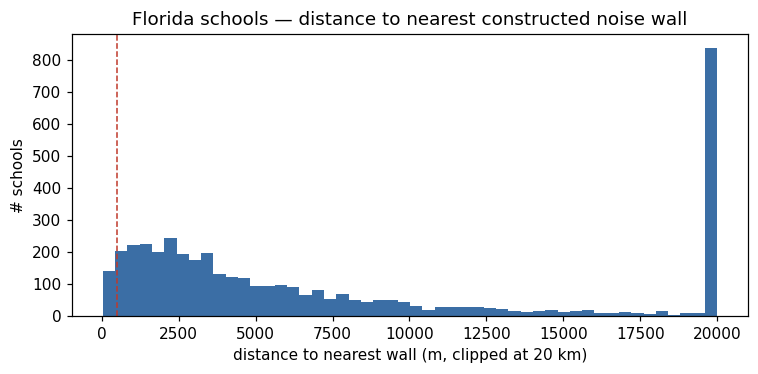

In [13]:
rows = []
for r in (100, 300, 500, 1000, 2000):
    hit = feat["dist_nearest_m"] <= r
    rows.append((r, hit.sum(), f"{hit.mean():.1%}",
                 round(feat.loc[hit, f'n_within_{r}'].mean(), 2) if f"n_within_{r}" in feat else np.nan))
print(pd.DataFrame(rows, columns=["buffer_m", "n_schools", "share_of_FL_schools", "mean_n_barriers"]).to_string(index=False))

print("\ndist_nearest_m distribution:")
print(feat["dist_nearest_m"].describe(percentiles=[.1, .25, .5, .75, .9]).round(0))

print("\ntop counties by share of schools within 500 m of a wall (>=20 schools):")
g = (feat.groupby("NMCNTY")
     .agg(n_schools=("dist_nearest_m", "size"),
          share_within_500m=("dist_nearest_m", lambda s: (s <= 500).mean())))
print(g[g.n_schools >= 20].sort_values("share_within_500m", ascending=False).head(10)
      .assign(share_within_500m=lambda d: (d.share_within_500m * 100).round(1)))

fig, ax = plt.subplots(figsize=(7, 3.5))
feat["dist_nearest_m"].clip(upper=20000).plot.hist(bins=50, ax=ax, color="#3b6ea5")
ax.axvline(500, color="#c0392b", ls="--", lw=1)
ax.set(xlabel="distance to nearest wall (m, clipped at 20 km)", ylabel="# schools",
       title="Florida schools — distance to nearest constructed noise wall")
fig.tight_layout()
savefig(fig, "schools_nearest_distance_hist.png")

### 6.1 Worked examples

wrote output/figures/florida/map_school_examples_grid.png


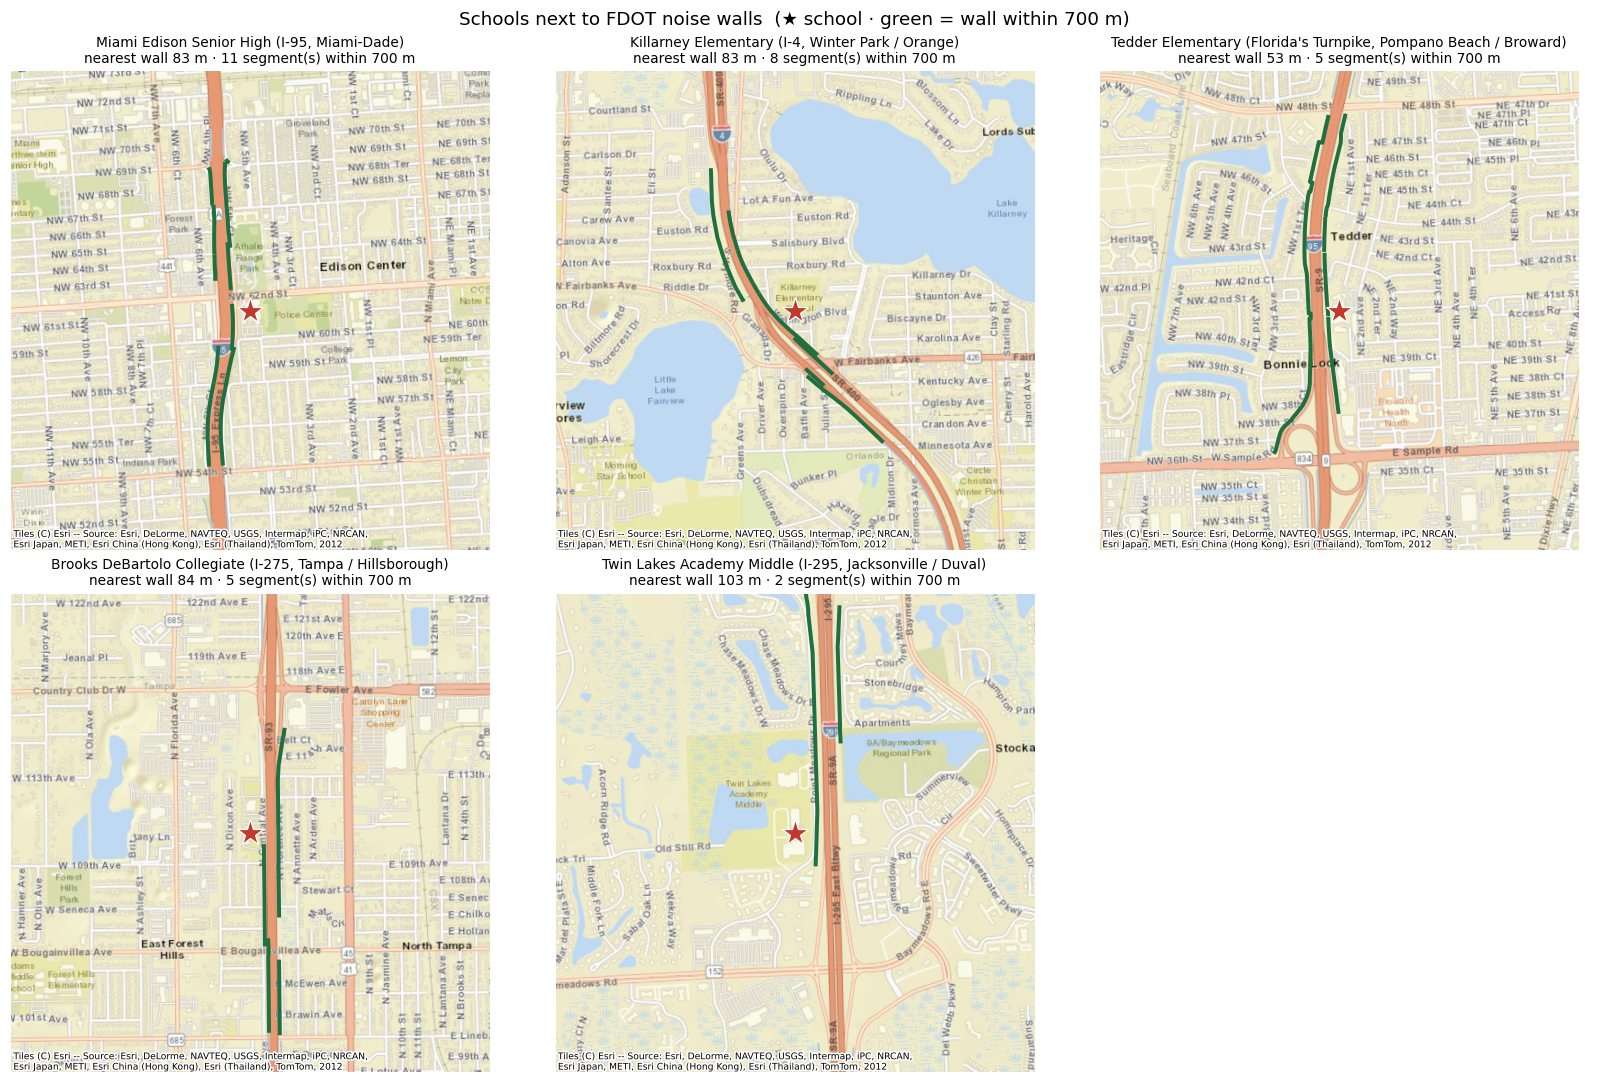

In [14]:
EXAMPLES = [
    ("120039000600", "Miami Edison Senior High (I-95, Miami-Dade)"),
    ("120144001378", "Killarney Elementary (I-4, Winter Park / Orange)"),
    ("120018000185", "Tedder Elementary (Florida's Turnpike, Pompano Beach / Broward)"),
    ("120087006987", "Brooks DeBartolo Collegiate (I-275, Tampa / Hillsborough)"),
    ("120048003361", "Twin Lakes Academy Middle (I-295, Jacksonville / Duval)"),
]


def school_panel(ax, nces, title, radius=700):
    s = schools.loc[schools["NCESSCH"] == nces].iloc[0]
    near = barriers_clean[barriers_clean.distance(s.geometry) <= radius]
    allb = barriers_clean[barriers_clean.distance(s.geometry) <= radius * 2.2]
    allb.plot(ax=ax, color="#b8c6d1", linewidth=1.2)
    near.plot(ax=ax, color="#1f6f3f", linewidth=2.6)
    ax.plot(s.geometry.x, s.geometry.y, marker="*", ms=18, color="#c0392b", mec="white", mew=0.8)
    cx_ = s.geometry.x; cy_ = s.geometry.y
    ax.set_xlim(cx_ - radius * 1.6, cx_ + radius * 1.6)
    ax.set_ylim(cy_ - radius * 1.6, cy_ + radius * 1.6)
    add_basemap(ax, source=BASEMAP_STREET)
    d = barriers_clean.distance(s.geometry).min()
    ax.set_title(f"{title}\nnearest wall {d:.0f} m · {len(near)} segment(s) within {radius} m",
                 fontsize=9)
    ax.set_axis_off()


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (nces, title) in zip(axes.flat, EXAMPLES):
    school_panel(ax, nces, title)
axes.flat[-1].set_axis_off()
fig.suptitle("Schools next to FDOT noise walls  (★ school · green = wall within 700 m)", fontsize=12)
fig.tight_layout()
savefig(fig, "map_school_examples_grid.png")

wrote output/figures/florida/map_school_120039000600.png


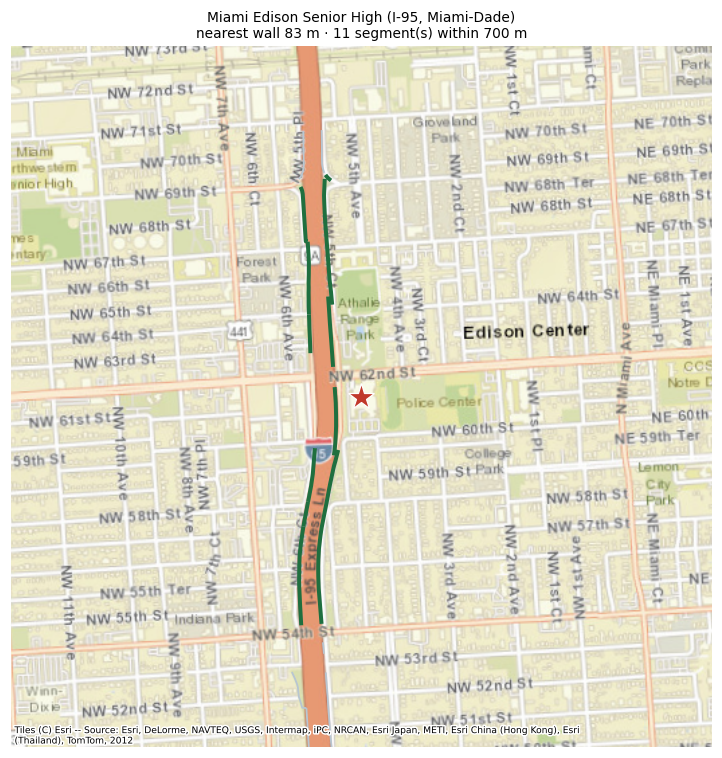

wrote output/figures/florida/map_school_120144001378.png


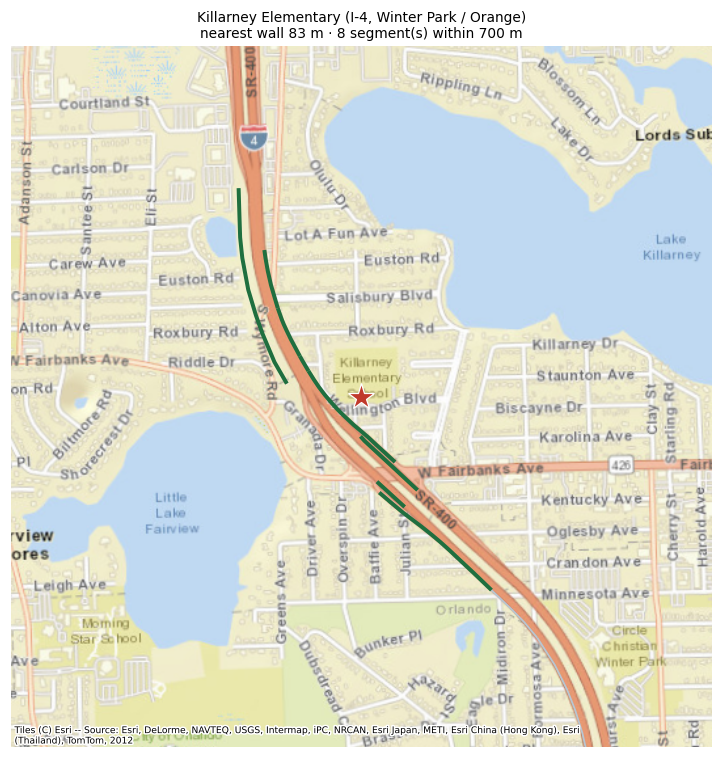

wrote output/figures/florida/map_school_120018000185.png


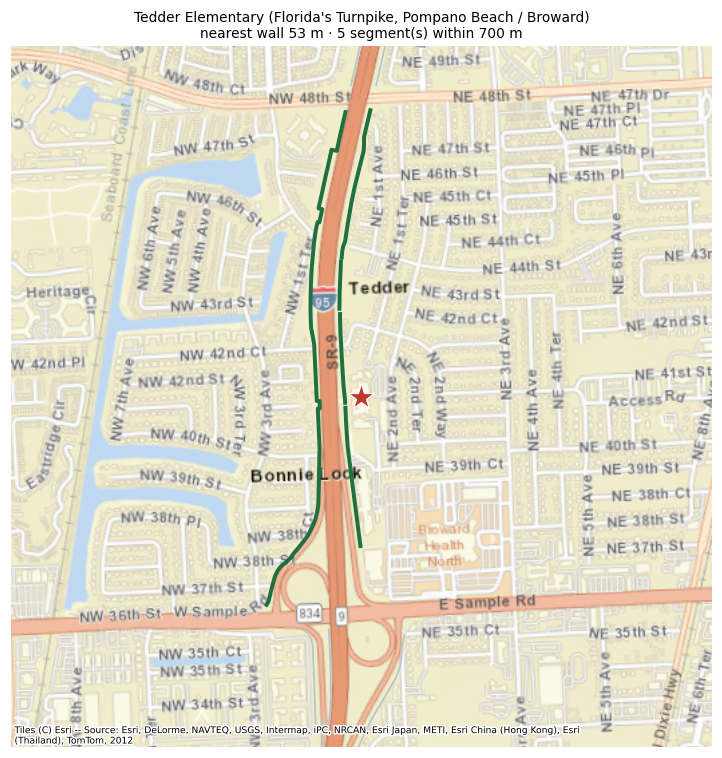

wrote output/figures/florida/map_school_120087006987.png


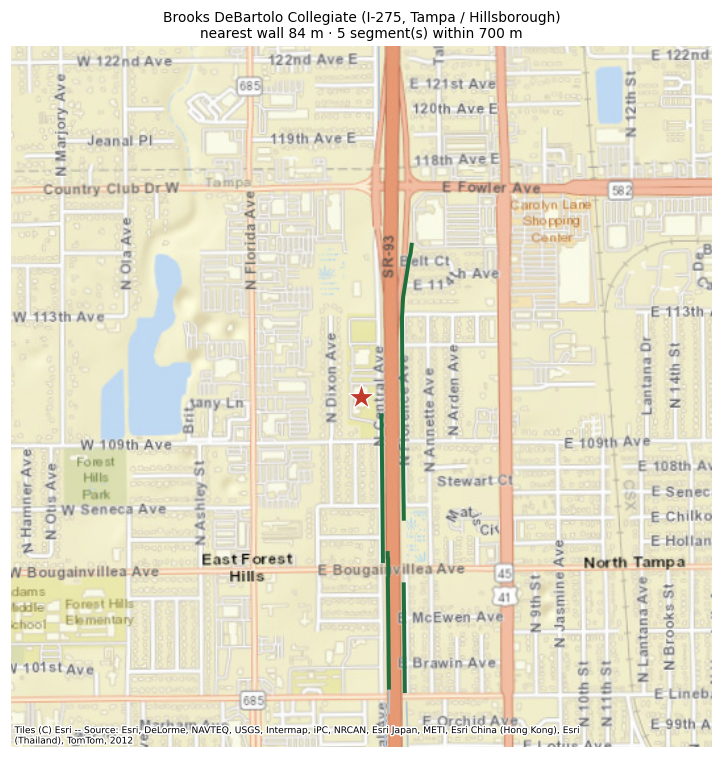

wrote output/figures/florida/map_school_120048003361.png


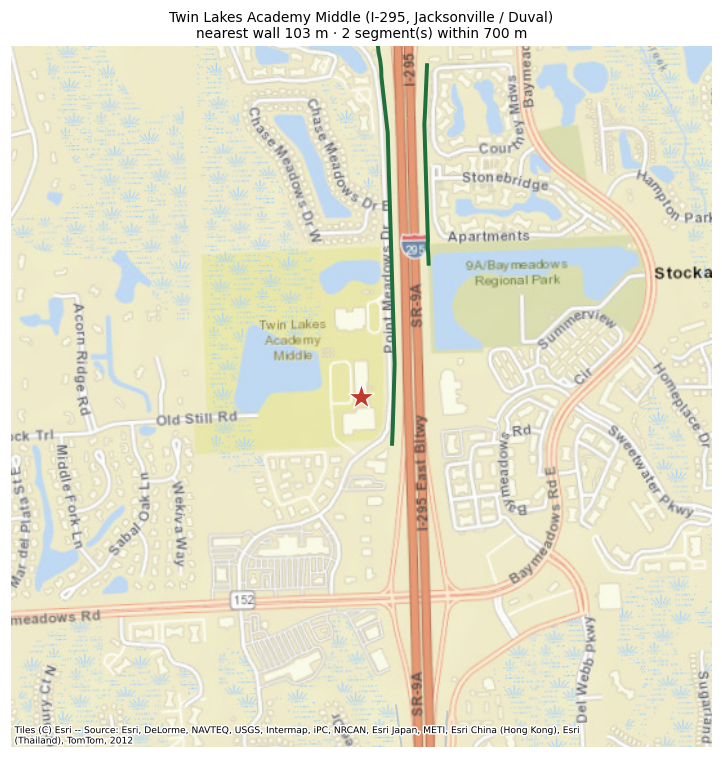

In [15]:
# Same five, one figure each (full-res, street basemap).
for nces, title in EXAMPLES:
    fig, ax = plt.subplots(figsize=(7, 7))
    school_panel(ax, nces, title, radius=700)
    fig.tight_layout()
    savefig(fig, f"map_school_{nces}.png")
    plt.show()

## 7. Persist outputs

The clean barrier layer is now produced by the pipeline
(`python -m src.cli florida data noise-barriers preprocess` →
`data/florida/noise_barriers/processed/barriers.parquet`), not by this notebook.
Only the exploratory per-school feature table is written here.

In [16]:
# The clean barrier layer + `other_walls` are now the `noise-barriers
# preprocess` step (src/regions/florida/sources/noise_barriers/preprocess.py);
# the section-4 cleaning rules are crystallized there. This notebook only
# persists its own exploratory per-school feature table.
sf_path = ROOT / "data/florida/schools/processed"
sf_path.mkdir(parents=True, exist_ok=True)
feat_path = sf_path / "school_barrier_features.parquet"

feat.to_parquet(feat_path)
print("wrote", feat_path.relative_to(ROOT), f"({feat_path.stat().st_size / 1024:.0f} KB)")

wrote data/florida/schools/processed/school_barrier_features.parquet (225 KB)


## Notes & caveats

- **Coverage bias.** The inventory is an *FDOT facility register*, not a census
  of every acoustic barrier. Walls on non-state roads, county berms and private
  screening are largely absent (`PRIVATE WALL` / `PERIMETER WALL` together are a
  handful of rows). Treat "distance to nearest wall" as "distance to nearest
  *state-highway* wall".
- **Construction year** is present for virtually all standing walls; the `9999`
  sentinel sits on `RECOMMENDED` / `REMOVED` rows, which are already dropped.
- **`barrier_len_within_500m`** sums whole segments that touch the buffer; for a
  precise exposure measure, clip `barriers_clean.geometry` to each school buffer
  and sum the clipped length.
- **Vintage mismatch.** The barrier snapshot is July 2026; the EDGE school
  geocodes are 2024–25, so a few walls post-date the school file and a few
  schools have opened/closed since. Co-located rows (virtual schools, shared
  campuses) inherit identical distances — dedupe on geometry if a
  school-building unit is wanted.
- **Next steps:** join `school_barrier_features` to test-score / enrollment
  panels; add a road-traffic-volume layer so a wall's presence can be read
  against the noise it is shielding.